# Практическая 13 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание

Практика по деревьям решений на задаче предсказания выживания пассажиров «Титаника».

Необходимо:

1. Обучить на имеющейся выборке дерево решений `DecisionTreeClassifier` максимальной глубины 2. Использовать `random_state=17` для воспроизводимости результатов.
2. Сделать с помощью полученной модели прогноз для тестовой выборки.
3. Ответить на вопросы и представить основные показатели качества модели.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [2]:
SEED = 17

## Загрузка данных

Используются файлы `titanic_train.csv` и `titanic_test.csv` из материалов практики.

In [3]:
train_raw = pd.read_csv('titanic_train.csv')
test_raw = pd.read_csv('titanic_test.csv')

train_raw.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('Train:', train_raw.shape)
print('Test:', test_raw.shape)
train_raw.info()

Train: (891, 12)
Test: (418, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_raw.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Первичный анализ

Посмотрим, как связаны пол, класс билета и выживаемость пассажиров.

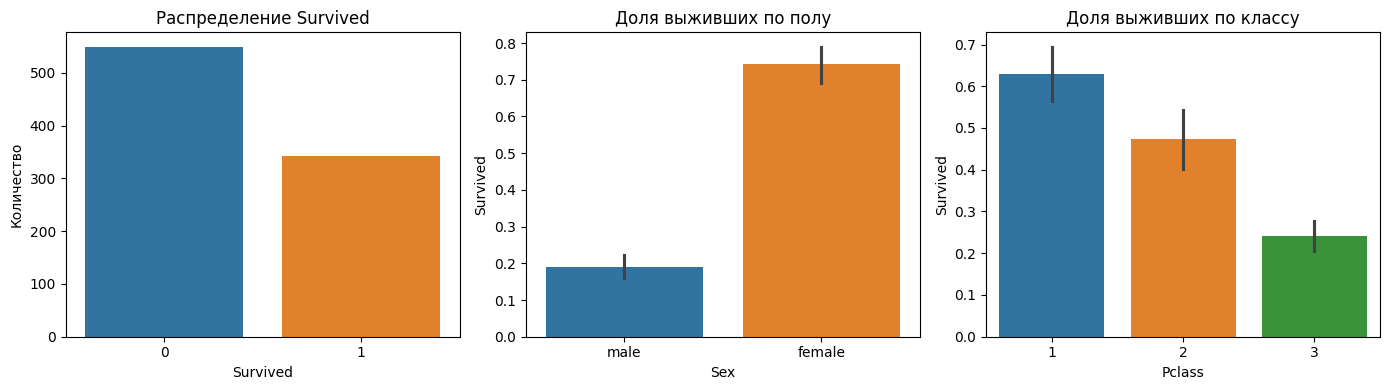

In [6]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
sns.countplot(data=train_raw, x='Survived', hue='Survived', palette='tab10', legend=False)
plt.title('Распределение Survived')
plt.xlabel('Survived')
plt.ylabel('Количество')

plt.subplot(1, 3, 2)
sns.barplot(data=train_raw, x='Sex', y='Survived', hue='Sex', palette='tab10', legend=False)
plt.title('Доля выживших по полу')

plt.subplot(1, 3, 3)
sns.barplot(data=train_raw, x='Pclass', y='Survived', hue='Pclass', palette='tab10', legend=False)
plt.title('Доля выживших по классу')

plt.tight_layout()
plt.show()

## Подготовка данных

Повторим подход из учебного ноутбука:

* пропуски в `Age` заполним медианой;
* пропуск в `Embarked` заполним самым частым значением `S`;
* пропуск в `Fare` в тестовой выборке заполним медианой из обучающей;
* категориальные признаки закодируем через One-Hot-Encoding;
* служебные и текстовые признаки удалим.

In [7]:
def prepare_titanic_data(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    y = train_df['Survived'].copy()
    test_passenger_id = test_df['PassengerId'].copy()

    train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
    test_df['Age'].fillna(train_df['Age'].median(), inplace=True)
    train_df['Embarked'].fillna('S', inplace=True)
    test_df['Fare'].fillna(train_df['Fare'].median(), inplace=True)

    # Дополнительный простой признак — размер семьи.
    train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
    test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1

    categorical_cols = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
    train_encoded = pd.get_dummies(train_df, columns=categorical_cols)
    test_encoded = pd.get_dummies(test_df, columns=categorical_cols)

    drop_cols_train = ['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId']
    drop_cols_test = ['Name', 'Ticket', 'Cabin', 'PassengerId']
    train_encoded.drop(columns=drop_cols_train, inplace=True)
    test_encoded.drop(columns=drop_cols_test, inplace=True)

    # Выравниваем наборы колонок, чтобы дерево получило одинаковые признаки в train и test.
    train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

    return train_encoded, test_encoded, y, test_passenger_id

X, X_test_final, y, test_passenger_id = prepare_titanic_data(train_raw, test_raw)

X.shape, X_test_final.shape

((891, 25), (418, 25))

In [8]:
X.head()

,Age,Fare,FamilySize,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp_0,SibSp_1,...,Parch_0,Parch_1,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Embarked_C,Embarked_Q,Embarked_S
0,22.0,7.2500,2,False,False,True,False,True,False,True,...,True,False,False,False,False,False,False,False,False,True
1,38.0,71.2833,2,True,False,False,True,False,False,True,...,True,False,False,False,False,False,False,True,False,False
2,26.0,7.9250,1,False,False,True,True,False,True,False,...,True,False,False,False,False,False,False,False,False,True
3,35.0,53.1000,2,True,False,False,True,False,False,True,...,True,False,False,False,False,False,False,False,False,True
4,35.0,8.0500,1,False,False,True,False,True,True,False,...,True,False,False,False,False,False,False,False,False,True


## Дерево решений с глубиной 2

По условию обучим `DecisionTreeClassifier(max_depth=2, random_state=17)`. Так как в тестовом файле нет правильных ответов, качество модели оценим на валидационной части обучающей выборки.

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

tree_depth_2 = DecisionTreeClassifier(max_depth=2, random_state=SEED)
tree_depth_2.fit(X_train, y_train)

valid_pred = tree_depth_2.predict(X_valid)
valid_proba = tree_depth_2.predict_proba(X_valid)[:, 1]

print('Accuracy:', round(accuracy_score(y_valid, valid_pred), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, valid_proba), 4))
print()
print(classification_report(y_valid, valid_pred))

Accuracy: 0.7803
ROC AUC: 0.806

              precision    recall  f1-score   support

           0       0.74      0.99      0.85       137
           1       0.95      0.45      0.61        86

    accuracy                           0.78       223
   macro avg       0.85      0.72      0.73       223
weighted avg       0.82      0.78      0.76       223



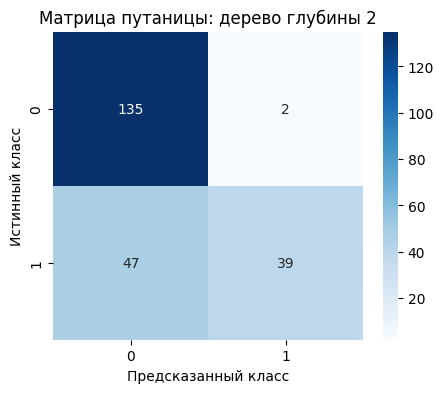

In [10]:
matrix = confusion_matrix(y_valid, valid_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица путаницы: дерево глубины 2')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

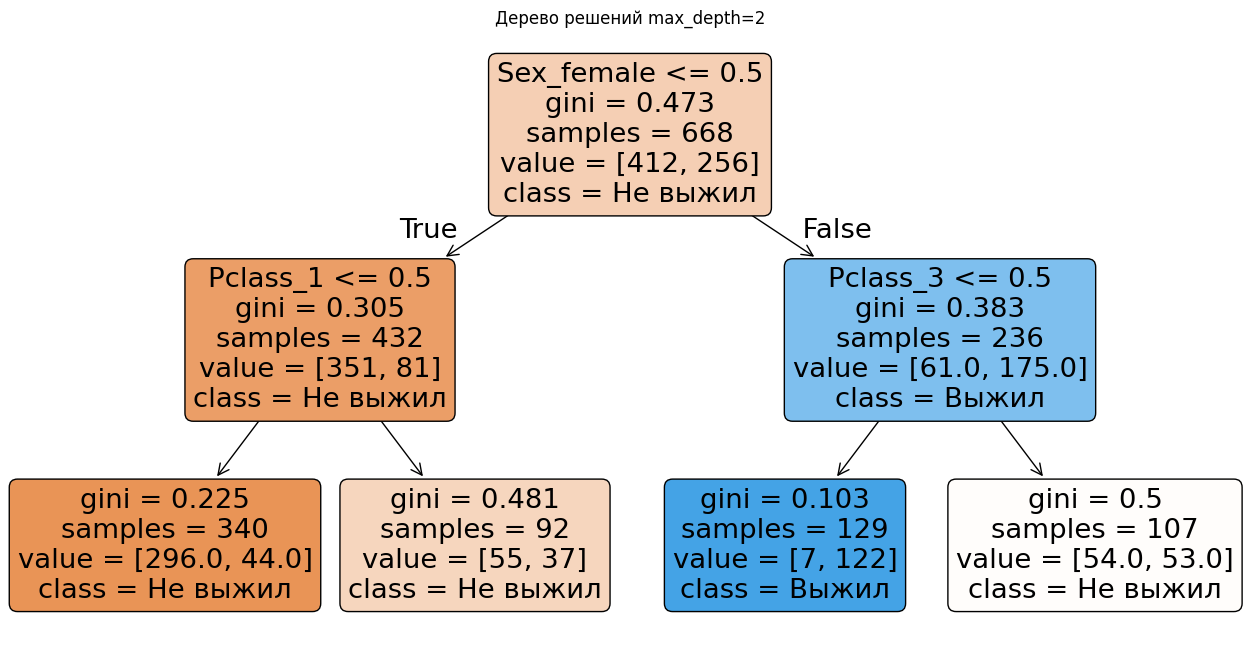

In [11]:
plt.figure(figsize=(16, 8))
plot_tree(
    tree_depth_2,
    feature_names=X.columns,
    class_names=['Не выжил', 'Выжил'],
    filled=True,
    rounded=True
)
plt.title('Дерево решений max_depth=2')
plt.show()

**Ответ на вопрос:** при глубине 2 дерево получается очень простым и хорошо интерпретируемым. В первых разбиениях обычно оказываются признаки, связанные с полом пассажира и классом билета. Это логично: по данным видно, что женщины и пассажиры более высокого класса выживали чаще.

## Подбор параметров дерева

Дополнительно проверим, как меняется качество при настройке глубины дерева и минимального числа объектов в листе. Это помогает избежать слишком простого дерева и переобучения.

In [12]:
params = {
    'max_depth': range(1, 11),
    'min_samples_leaf': range(1, 11),
    'criterion': ['gini', 'entropy']
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print('Лучшие параметры:', grid_tree.best_params_)
print('Лучший CV accuracy:', round(grid_tree.best_score_, 4))

Лучшие параметры: {'criterion': 'gini', 'max_depth': 9, 'min_samples_leaf': 8}
Лучший CV accuracy: 0.8113


In [13]:
best_tree = grid_tree.best_estimator_
best_pred = best_tree.predict(X_valid)
best_proba = best_tree.predict_proba(X_valid)[:, 1]

print('Accuracy:', round(accuracy_score(y_valid, best_pred), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, best_proba), 4))
print()
print(classification_report(y_valid, best_pred))

Accuracy: 0.8072
ROC AUC: 0.8598

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       137
           1       0.77      0.71      0.74        86

    accuracy                           0.81       223
   macro avg       0.80      0.79      0.79       223
weighted avg       0.81      0.81      0.81       223



## Сравнение с RandomForest

В материалах практики также импортировался `RandomForestClassifier`. Сравним дерево решений с ансамблем деревьев. Random Forest обычно дает более устойчивый результат, потому что усредняет ответы многих деревьев.

In [14]:
forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=SEED,
    n_jobs=-1
)
forest.fit(X_train, y_train)

forest_pred = forest.predict(X_valid)
forest_proba = forest.predict_proba(X_valid)[:, 1]

print('Accuracy:', round(accuracy_score(y_valid, forest_pred), 4))
print('ROC AUC:', round(roc_auc_score(y_valid, forest_proba), 4))
print()
print(classification_report(y_valid, forest_pred))

Accuracy: 0.8072
ROC AUC: 0.8575

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       137
           1       0.79      0.67      0.73        86

    accuracy                           0.81       223
   macro avg       0.80      0.78      0.79       223
weighted avg       0.81      0.81      0.80       223



In [15]:
comparison = pd.DataFrame({
    'Модель': ['DecisionTree max_depth=2', 'DecisionTree tuned', 'RandomForest'],
    'Accuracy': [
        accuracy_score(y_valid, valid_pred),
        accuracy_score(y_valid, best_pred),
        accuracy_score(y_valid, forest_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_valid, valid_proba),
        roc_auc_score(y_valid, best_proba),
        roc_auc_score(y_valid, forest_proba)
    ]
})

comparison

,Модель,Accuracy,ROC AUC
0,DecisionTree max_depth=2,0.780269,0.805975
1,DecisionTree tuned,0.807175,0.859829
2,RandomForest,0.807175,0.857494


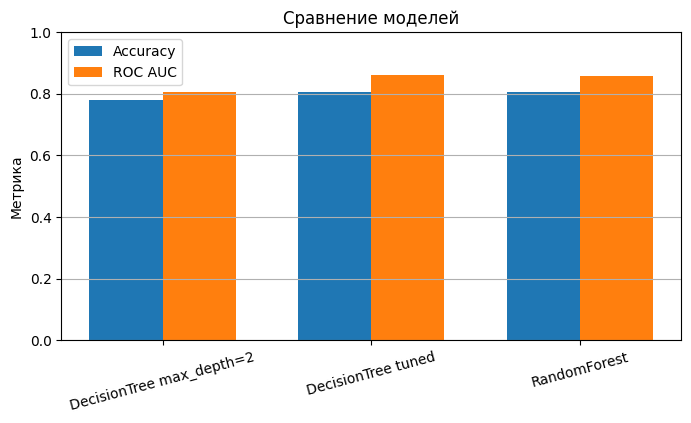

In [16]:
plt.figure(figsize=(8, 4))
x = np.arange(len(comparison['Модель']))
width = 0.35

plt.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy')
plt.bar(x + width/2, comparison['ROC AUC'], width, label='ROC AUC')
plt.xticks(x, comparison['Модель'], rotation=15)
plt.ylim(0, 1)
plt.title('Сравнение моделей')
plt.ylabel('Метрика')
plt.legend()
plt.grid(axis='y')
plt.show()

## Прогноз для тестовой выборки

По условию сделаем прогноз для тестовой выборки. Для финального прогноза обучим дерево глубины 2 на всей обучающей выборке и сохраним результат в CSV-файл.

In [17]:
final_tree = DecisionTreeClassifier(max_depth=2, random_state=SEED)
final_tree.fit(X, y)

test_predictions = final_tree.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test_passenger_id,
    'Survived': test_predictions
})

submission.to_csv('titanic_tree_submission.csv', index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [18]:
print('Файл сохранен: titanic_tree_submission.csv')
print('Распределение предсказаний:')
print(submission['Survived'].value_counts().sort_index())

Файл сохранен: titanic_tree_submission.csv
Распределение предсказаний:
Survived
0    330
1     88
Name: count, dtype: int64


## Вывод

В практической работе была решена задача предсказания выживания пассажиров «Титаника» с помощью дерева решений.

Сначала данные были подготовлены: заполнены пропуски, категориальные признаки преобразованы через One-Hot-Encoding, а обучающая и тестовая выборки приведены к одинаковому набору признаков.

По заданию была обучена модель `DecisionTreeClassifier(max_depth=2, random_state=17)`. Такое дерево легко интерпретировать: оно использует несколько наиболее важных правил, связанных прежде всего с полом пассажира и классом билета. Дополнительно был выполнен подбор параметров дерева и сравнение с `RandomForestClassifier`.

Финальный прогноз для тестовой выборки сохранен в файл `titanic_tree_submission.csv`.